In [ ]:
!pip install -q transformers datasets evaluate rouge_score accelerate

In [21]:
import torch
import numpy as np

from datasets import load_from_disk
from transformers import (
    BartTokenizer,
    BartForConditionalGeneration,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments
)
import pandas as pd
import matplotlib.pyplot as plt
import evaluate

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
data_path = "/content/drive/MyDrive/nlp_summarization_project/tokenized_cnn_dailymail_bart_base"

dataset = load_from_disk(data_path)
dataset

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 287113
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 13368
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 11490
    })
})

In [5]:
small_train = dataset["train"].shuffle(seed=42).select(range(20000))
small_val = dataset["validation"].shuffle(seed=42).select(range(500))
small_test = dataset["test"].shuffle(seed=42).select(range(500))

from datasets import DatasetDict

small_dataset = DatasetDict({
    "train": small_train,
    "validation": small_val,
    "test": small_test
})

small_dataset

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 20000
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 500
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 500
    })
})

In [ ]:
model_name = "facebook/bart-base"

tokenizer = BartTokenizer.from_pretrained(model_name)
model = BartForConditionalGeneration.from_pretrained(model_name)

In [7]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model
)

In [ ]:
rouge = evaluate.load("rouge")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    if isinstance(predictions, tuple):
        predictions = predictions[0]

    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)

    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    result = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True
    )

    return {
        "rouge1": result["rouge1"],
        "rouge2": result["rouge2"],
        "rougeL": result["rougeL"]
    }

In [9]:
training_args = Seq2SeqTrainingArguments(
    output_dir="/content/drive/MyDrive/nlp_summarization_project/bart_results",

    eval_strategy="steps",
    eval_steps=500,

    save_strategy="steps",
    save_steps=500,

    logging_steps=100,

    learning_rate=3e-5,

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,

    weight_decay=0.01,
    num_train_epochs=1,

    save_total_limit=2,

    predict_with_generate=True,
    fp16=torch.cuda.is_available(),

)

In [11]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=small_dataset["train"],
    eval_dataset=small_dataset["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [12]:
trainer.train()

Step,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel
500,4.777166,1.072829,0.251294,0.124463,0.208607
1000,4.591624,1.047164,0.253251,0.126239,0.209559


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1250, training_loss=5.705203063964844, metrics={'train_runtime': 818.1394, 'train_samples_per_second': 24.446, 'train_steps_per_second': 1.528, 'total_flos': 6097364582400000.0, 'train_loss': 5.705203063964844, 'epoch': 1.0})

In [14]:

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

test_sample = small_dataset["test"][0]

input_ids = torch.tensor(test_sample["input_ids"]).unsqueeze(0).to(device)

summary_ids = model.generate(
    input_ids,
    max_length=128,
    num_beams=4,
    early_stopping=True
)

generated_summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

print("GENERATED SUMMARY:\n")
print(generated_summary)

GENERATED SUMMARY:

The medical marijuana revolution is burning white hot among young people, but also shows up among parents and grandparents .
The first time a majority, 53%, favor its legalization, with 77% supporting it for medical purposes .


In [20]:
import torch
from datasets import load_dataset, load_from_disk
from transformers import BartTokenizer, BartForConditionalGeneration

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

raw_dataset = load_dataset("abisee/cnn_dailymail", "3.0.0")
tokenized_dataset = load_from_disk("/content/drive/MyDrive/nlp_summarization_project/tokenized_cnn_dailymail_bart_base")

raw_small_test = raw_dataset["test"].shuffle(seed=42).select(range(500))
token_small_test = tokenized_dataset["test"].shuffle(seed=42).select(range(500))

model_path = "/content/drive/MyDrive/nlp_summarization_project/bart_results/checkpoint-1250"

tokenizer = BartTokenizer.from_pretrained(model_path, local_files_only=True)
model = BartForConditionalGeneration.from_pretrained(model_path, local_files_only=True).to(device)

for i in range(3):
    raw_sample = raw_small_test[i]
    test_sample = token_small_test[i]

    input_ids = torch.tensor(test_sample["input_ids"]).unsqueeze(0).to(device)

    summary_ids = model.generate(
        input_ids,
        max_length=128,
        num_beams=4,
        early_stopping=True
    )

    generated_summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

    print(f"\n{'='*40} SAMPLE {i+1} {'='*40}\n")
    print("ARTICLE:\n")
    print(raw_sample["article"][:1500])

    print("\n" + "-"*90 + "\n")
    print("REFERENCE SUMMARY:\n")
    print(raw_sample["highlights"])

    print("\n" + "-"*90 + "\n")
    print("GENERATED SUMMARY:\n")
    print(generated_summary)

Using device: cuda


Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]


======================================== SAMPLE 1 ========================================

ARTICLE:

(CNN) I see signs of a revolution everywhere. I see it in the op-ed pages of the newspapers, and on the state ballots in nearly half the country. I see it in politicians who once preferred to play it safe with this explosive issue but are now willing to stake their political futures on it. I see the revolution in the eyes of sterling scientists, previously reluctant to dip a toe into this heavily stigmatized world, who are diving in head first. I see it in the new surgeon general who cites data showing just how helpful it can be. I see a revolution in the attitudes of everyday Americans. For the first time a majority, 53%, favor its legalization, with 77% supporting it for medical purposes. Support for legalization has risen 11 points in the past few years alone. In 1969, the first time Pew asked the question about legalization, only 12% of the nation was in favor. I see a revolution 

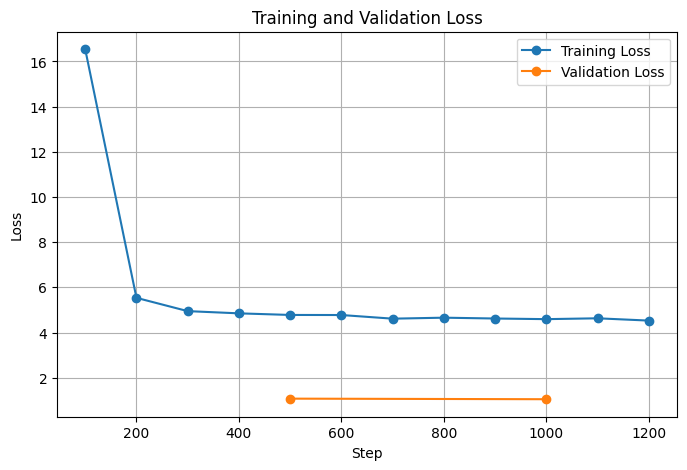

In [23]:
plt.figure(figsize=(8,5))

if "loss" in log_df.columns:
    train_logs = log_df.dropna(subset=["loss", "step"])
    plt.plot(train_logs["step"], train_logs["loss"], marker="o", label="Training Loss")

if "eval_loss" in log_df.columns:
    eval_logs = log_df.dropna(subset=["eval_loss", "step"])
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], marker="o", label="Validation Loss")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

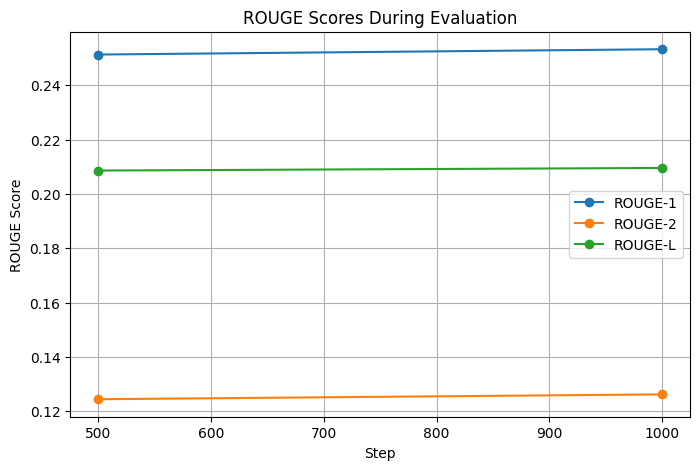

In [26]:
eval_metric_logs = log_df.dropna(subset=["eval_rouge1", "eval_rouge2", "eval_rougeL", "step"])

plt.figure(figsize=(8,5))
plt.plot(eval_metric_logs["step"], eval_metric_logs["eval_rouge1"], marker="o", label="ROUGE-1")
plt.plot(eval_metric_logs["step"], eval_metric_logs["eval_rouge2"], marker="o", label="ROUGE-2")
plt.plot(eval_metric_logs["step"], eval_metric_logs["eval_rougeL"], marker="o", label="ROUGE-L")

plt.xlabel("Step")
plt.ylabel("ROUGE Score")
plt.title("ROUGE Scores During Evaluation")
plt.legend()
plt.grid(True)
plt.show()